# 02 - Clean + Filter + Impute (ALI dataset)

This notebook:
1) Loads `data/raw/wdi_2022_initial.csv`
2) Removes aggregates using the World Bank country metadata (region != "Aggregates")
3) Selects the baseline indicator set (dropping PM2.5 and homicide due to missingness)
4) Applies missingness rules (drop countries with too much missing data)
5) Imputes remaining missing values (KNN imputation baseline)
6) Saves `data/processed/ali_2022_imputed.csv`

In [1]:
import pandas as pd
import numpy as np
import requests

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer

In [2]:
RAW_PATH = "../data/raw/wdi_2022_initial.csv"
df = pd.read_csv(RAW_PATH)
df.head(), df.shape

(                       country iso3  year  gdp_per_capita_ppp_const  \
 0                        Aruba  ABW  2022              38979.835825   
 1  Africa Eastern and Southern  AFE  2022               4106.501907   
 2                  Afghanistan  AFG  2022               1981.710168   
 3   Africa Western and Central  AFW  2022               5806.172890   
 4                       Angola  AGO  2022               8950.142593   
 
    unemployment_rate  labor_force_participation  life_expectancy  \
 0                NaN                        NaN        76.226000   
 1           7.869470                  66.397433        64.487152   
 2          14.100000                  37.640000        65.617000   
 3           3.593354                  71.942794        57.987850   
 4          14.124000                  75.247000        64.246000   
 
    pm25_exposure  homicide_rate  ppp_conversion_factor  
 0            NaN            NaN               1.327790  
 1            NaN           12.7  

In [3]:
indicator_cols_all = [
    "gdp_per_capita_ppp_const",
    "unemployment_rate",
    "labor_force_participation",
    "life_expectancy",
    "pm25_exposure",
    "homicide_rate",
    "ppp_conversion_factor"
]

for c in indicator_cols_all:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df[indicator_cols_all].isna().mean().sort_values(ascending=False)

pm25_exposure                1.000000
homicide_rate                0.536585
ppp_conversion_factor        0.191057
unemployment_rate            0.126016
labor_force_participation    0.126016
gdp_per_capita_ppp_const     0.073171
life_expectancy              0.000000
dtype: float64

In [4]:
def fetch_world_bank_country_metadata() -> pd.DataFrame:
    # per_page big enough for all entities
    url = "https://api.worldbank.org/v2/country?format=json&per_page=400"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    payload = r.json()
    records = payload[1] or []
    meta = pd.json_normalize(records)

    # Keep only what is needed
    keep = [
        "id",                      # ISO2
        "iso2Code",
        "name",
        "region.id",
        "region.value",
        "incomeLevel.id",
        "incomeLevel.value",
        "lendingType.id",
        "lendingType.value"
    ]
    meta = meta[keep].copy()
    meta.rename(columns={"name": "wb_name"}, inplace=True)
    return meta

meta = fetch_world_bank_country_metadata()
meta.head(), meta.shape

(    id iso2Code                      wb_name region.id  \
 0  ABW       AW                        Aruba       LCN   
 1  AFE       ZH  Africa Eastern and Southern        NA   
 2  AFG       AF                  Afghanistan       MEA   
 3  AFR       A9                       Africa        NA   
 4  AFW       ZI   Africa Western and Central        NA   
 
                                         region.value incomeLevel.id  \
 0                         Latin America & Caribbean             HIC   
 1                                         Aggregates             NA   
 2  Middle East, North Africa, Afghanistan & Pakistan            LIC   
 3                                         Aggregates             NA   
 4                                         Aggregates             NA   
 
   incomeLevel.value lendingType.id lendingType.value  
 0       High income            LNX    Not classified  
 1        Aggregates                       Aggregates  
 2        Low income            IDX       

In [5]:
# Join on country name
df2 = df.merge(meta, left_on="country", right_on="wb_name", how="left")

# Filter out aggregates: region.value == "Aggregates"
# Also remove rows where region.value is missing
before = df2.shape[0]
df2 = df2[df2["region.value"].notna()].copy()
df2 = df2[df2["region.value"] != "Aggregates"].copy()
after = df2.shape[0]

print("Rows before:", before)
print("Rows after removing aggregates:", after)

df2[["country","iso3","region.value","incomeLevel.value"]].head()

Rows before: 246
Rows after removing aggregates: 217


,country,iso3,region.value,incomeLevel.value
0,Aruba,ABW,Latin America & Caribbean,High income
2,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income
4,Angola,AGO,Sub-Saharan Africa,Lower middle income
5,Albania,ALB,Europe & Central Asia,Upper middle income
6,Andorra,AND,Europe & Central Asia,High income


In [6]:
# Baseline indicators for 2022 (WDI pull):
# - PM2.5 is fully missing in 2022 pull
# - homicide is very sparse (~54% missing)
INDICATORS_BASELINE = [
    "gdp_per_capita_ppp_const",
    "unemployment_rate",
    "labor_force_participation",
    "life_expectancy",
    "ppp_conversion_factor"
]

dfb = df2[["country","iso3","year"] + INDICATORS_BASELINE].copy()

missing_base = dfb[INDICATORS_BASELINE].isna().mean().sort_values(ascending=False)
missing_base

unemployment_rate            0.142857
labor_force_participation    0.142857
gdp_per_capita_ppp_const     0.082949
ppp_conversion_factor        0.082949
life_expectancy              0.000000
dtype: float64

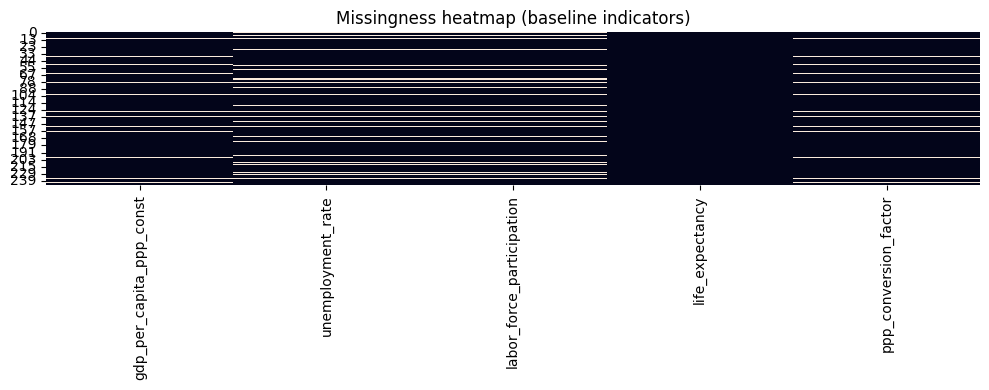

In [7]:
plt.figure(figsize=(10, 4))
sns.heatmap(dfb[INDICATORS_BASELINE].isna(), cbar=False)
plt.title("Missingness heatmap (baseline indicators)")
plt.tight_layout()
plt.show()

In [8]:
# Rule: drop countries missing more than 40% of baseline indicators
# (With 5 indicators, that means drop if missing >= 3 indicators)
max_missing_share = 0.40

row_missing_share = dfb[INDICATORS_BASELINE].isna().mean(axis=1)
dfb["missing_share"] = row_missing_share

before = dfb.shape[0]
dfb = dfb[dfb["missing_share"] <= max_missing_share].copy()
after = dfb.shape[0]

print("Countries before rule:", before)
print("Countries after rule:", after)
dfb["missing_share"].describe()

Countries before rule: 217
Countries after rule: 209


count    209.000000
mean       0.063158
std        0.146207
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.400000
Name: missing_share, dtype: float64

In [9]:
# KNN imputation
imputer = KNNImputer(n_neighbors=5, weights="distance")

X = dfb[INDICATORS_BASELINE].to_numpy()
X_imp = imputer.fit_transform(X)

df_imp = dfb.copy()
df_imp[INDICATORS_BASELINE] = X_imp

# Confirm no missing values remain
df_imp[INDICATORS_BASELINE].isna().sum()

gdp_per_capita_ppp_const     0
unemployment_rate            0
labor_force_participation    0
life_expectancy              0
ppp_conversion_factor        0
dtype: int64

In [10]:
OUT_PATH = "../data/processed/ali_2022_imputed.csv"
df_imp.drop(columns=["missing_share"]).to_csv(OUT_PATH, index=False)
OUT_PATH, df_imp.shape

('../data/processed/ali_2022_imputed.csv', (209, 9))

In [11]:
df_imp[INDICATORS_BASELINE].describe().T

,count,mean,std,min,25%,50%,75%,max
gdp_per_capita_ppp_const,209.0,26656.150004,26177.782345,1031.254122,6418.174984,17119.574495,39864.010088,133571.962410
unemployment_rate,209.0,7.235356,5.567440,0.130000,3.591000,5.570000,9.250000,36.472000
labor_force_participation,209.0,60.342851,10.623449,23.509000,55.218000,60.835000,65.964000,87.575000
life_expectancy,209.0,72.830015,7.923014,18.818000,67.675000,74.125000,77.911000,85.708000
ppp_conversion_factor,209.0,630.143802,5037.720877,0.085160,0.918072,4.624378,84.098765,71200.145632


'../outputs/figures/missingness_baseline.png'

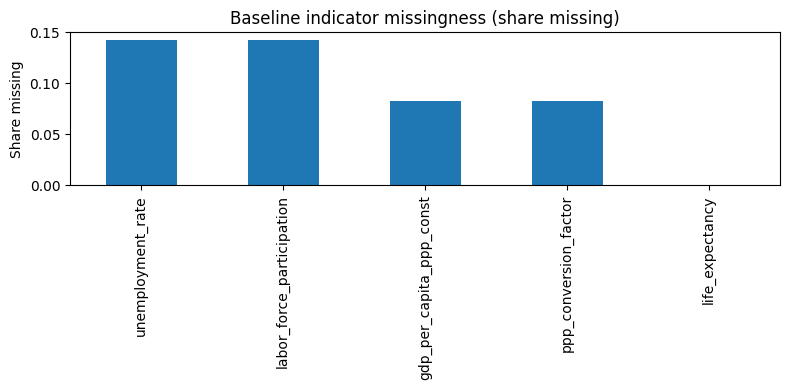

In [12]:
missing_base = df2[INDICATORS_BASELINE].isna().mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
missing_base.plot(kind="bar")
plt.title("Baseline indicator missingness (share missing)")
plt.ylabel("Share missing")
plt.tight_layout()

fig_path = "../outputs/figures/missingness_baseline.png"
plt.savefig(fig_path, dpi=200)
fig_path